Mohammed Naif Alhadi -- 2240007563 -- 7MA2

In [2]:
!pip install scikit-image

   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
    --------------------------------------- 0.3/11.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/11.9 MB 5.6 MB/s eta 0:00:02
   ------- -------------------------------- 2.4/11.9 MB 6.5 MB/s eta 0:00:02
   ------------------ --------------------- 5.5/11.9 MB 7.8 MB/s eta 0:00:01
   ---------------------------- ----------- 8.4/11.9 MB 9.3 MB/s eta 0:00:01
   -------------------------------- ------- 9.7/11.9 MB 8.8 MB/s eta 0:00:01
   ---------------------------------------- 11.9/11.9 MB 9.9 MB/s  0:00:01
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------- ----- 1.8/2.1 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 6.0 MB/s  0:00:00

   ---------------------------------------- 0/5 [tifffile]
   ---------------------------------------- 0/5 [tifffile]
   ---------------------------------------- 0/5 [tifffile]
   -

In [3]:
# Import required libraries
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, exposure
from skimage.exposure import match_histograms

# Save dataset images locally for GitHub submission
plt.imsave('moon.png', data.moon(), cmap='gray')
plt.imsave('rocket.png', data.rocket())
plt.imsave('chelsea.png', data.chelsea())

print("Libraries imported and images saved successfully!")

Libraries imported and images saved successfully!


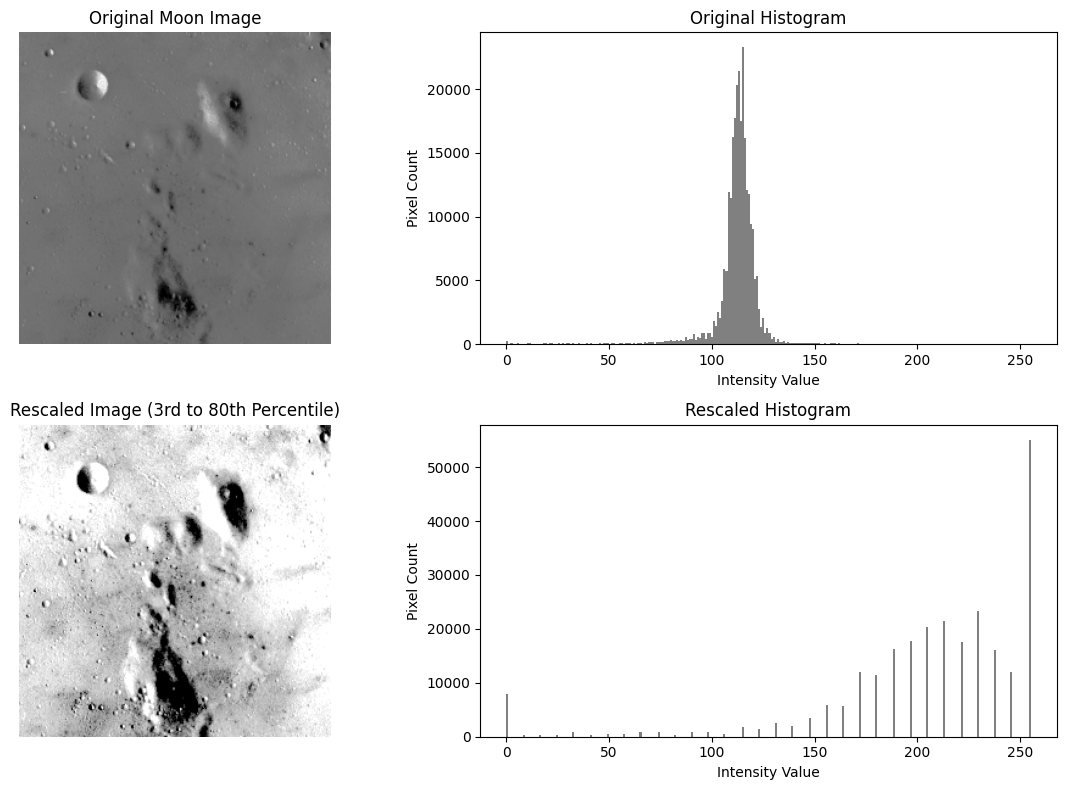

In [4]:
# Task 1: Rescale intensity values between 3rd and 80th percentiles

# Load the moon image
moon_img = data.moon()

# Compute the 3rd and 80th percentiles
p3, p80 = np.percentile(moon_img, (3, 80))

# Apply contrast stretching using rescale_intensity
img_rescaled = exposure.rescale_intensity(moon_img, in_range=(p3, p80))

# Plot the original and rescaled images alongside their histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Original image display
axes[0, 0].imshow(moon_img, cmap='gray')
axes[0, 0].set_title('Original Moon Image')
axes[0, 0].axis('off')

# Original histogram plot
axes[0, 1].hist(moon_img.ravel(), bins=256, range=(0, 255), color='gray')
axes[0, 1].set_title('Original Histogram')
axes[0, 1].set_xlabel('Intensity Value')
axes[0, 1].set_ylabel('Pixel Count')

# Rescaled image display
axes[1, 0].imshow(img_rescaled, cmap='gray')
axes[1, 0].set_title('Rescaled Image (3rd to 80th Percentile)')
axes[1, 0].axis('off')

# Rescaled histogram plot
axes[1, 1].hist(img_rescaled.ravel(), bins=256, range=(0, 255), color='gray')
axes[1, 1].set_title('Rescaled Histogram')
axes[1, 1].set_xlabel('Intensity Value')
axes[1, 1].set_ylabel('Pixel Count')

plt.tight_layout()
plt.show()

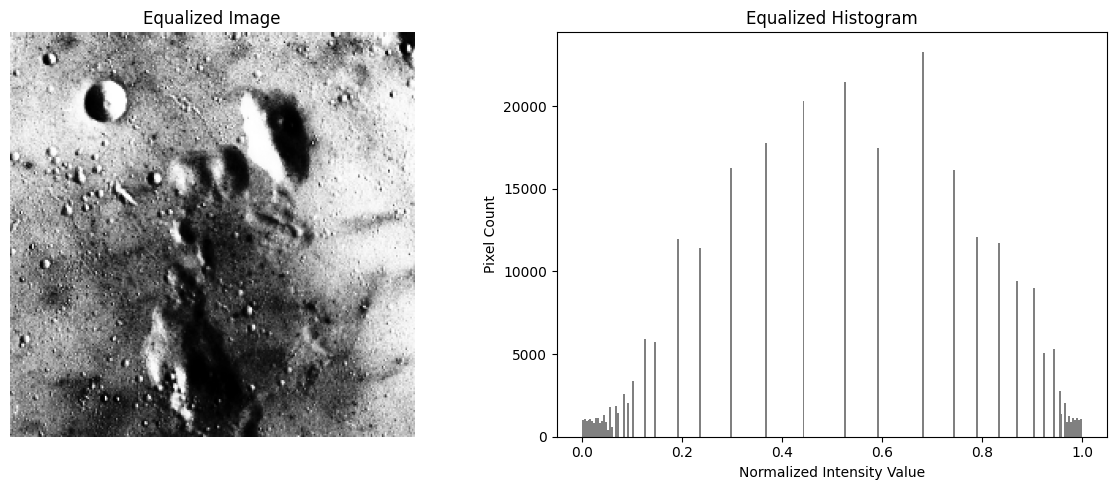

In [5]:
# Task 2: Histogram Equalization using exposure.equalize_hist

# Apply histogram equalization to flatten the distribution
img_equalized = exposure.equalize_hist(moon_img)

# Display the equalized image and its corresponding histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Equalized image display
axes[0].imshow(img_equalized, cmap='gray')
axes[0].set_title('Equalized Image')
axes[0].axis('off')

# Equalized histogram plot (values are normalized between 0.0 and 1.0)
axes[1].hist(img_equalized.ravel(), bins=256, range=(0.0, 1.0), color='gray')
axes[1].set_title('Equalized Histogram')
axes[1].set_xlabel('Normalized Intensity Value')
axes[1].set_ylabel('Pixel Count')

plt.tight_layout()
plt.show()

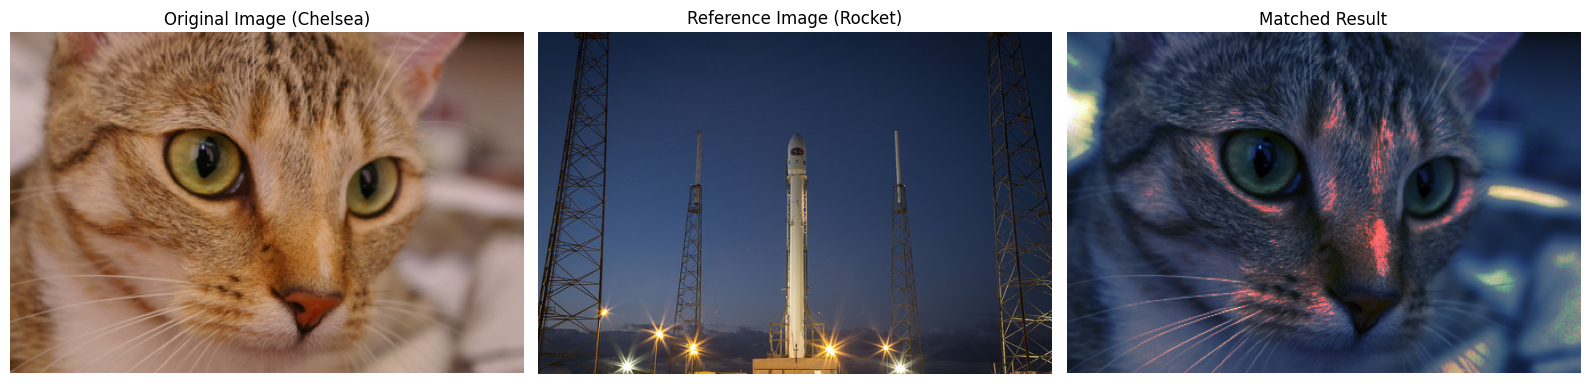

In [6]:
# Task 3: Histogram Matching between Chelsea and Rocket images

# Load images from skimage.data
image = data.chelsea()        # Source image to modify
reference = data.rocket()      # Reference image

# Apply histogram matching for color images
matched = match_histograms(image, reference, channel_axis=-1)

# Display the source, reference, and matched images side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Source image display
axes[0].imshow(image)
axes[0].set_title('Original Image (Chelsea)')
axes[0].axis('off')

# Reference image display
axes[1].imshow(reference)
axes[1].set_title('Reference Image (Rocket)')
axes[1].axis('off')

# Matched result display
axes[2].imshow(matched)
axes[2].set_title('Matched Result')
axes[2].axis('off')

plt.tight_layout()
plt.show()